<a href="https://colab.research.google.com/github/Amjadkp/ComputerVisionLab/blob/main/Feature_Matching_Affine_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install opencv-contrib-python

In [8]:
import cv2

# Load the images
img_close = cv2.imread('/content/image1.png')
img_open = cv2.imread('/content/image2.png')

print("Images loaded successfully.")

Images loaded successfully.


In [9]:

import numpy as np

# 1. Convert images to grayscale
gray_close = cv2.cvtColor(img_close, cv2.COLOR_BGR2GRAY)
gray_open = cv2.cvtColor(img_open, cv2.COLOR_BGR2GRAY)
print("Images converted to grayscale.")

# 2. Initialize SIFT detector
sift = cv2.SIFT_create()
print("SIFT detector initialized.")

# 3. Detect keypoints and compute descriptors
kp_close, des_close = sift.detectAndCompute(gray_close, None)
kp_open, des_open = sift.detectAndCompute(gray_open, None)
print(f"Detected {len(kp_close)} keypoints in img_close and {len(kp_open)} keypoints in img_open.")

# Re-initialize Brute-Force Matcher (or use the existing one 'bf')
bf = cv2.BFMatcher()
print("Brute-Force Matcher initialized.")

# Find k-nearest neighbors (k=2) for each descriptor
matches = bf.knnMatch(des_close, des_open, k=2)
print(f"Found {len(matches)} potential matches.")

# Apply ratio test to filter good matches with a less strict threshold
good_matches = []
RATIO_TEST_THRESHOLD = 0.8 # Adjusted threshold
for m, n in matches:
    if m.distance < RATIO_TEST_THRESHOLD * n.distance:
        good_matches.append(m)
print(f"Filtered down to {len(good_matches)} good matches using adjusted ratio test (threshold={RATIO_TEST_THRESHOLD}).")

# Extract coordinates of matched keypoints and estimate homography
MIN_MATCHES_FOR_HOMOGRAPHY = 4 # Adjusted minimum matches required for homography estimation
if len(good_matches) >= MIN_MATCHES_FOR_HOMOGRAPHY:
    src_pts = np.float32([kp_close[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_open[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    print("Extracted matched keypoint coordinates.")

    # Estimate homography matrix using RANSAC
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    if M is not None:
        print("Homography matrix estimated successfully.")

        # Warp img_close using the estimated homography matrix
        h, w, _ = img_open.shape
        img_registered = img_close.copy()
    else:
        print("Could not estimate homography matrix with adjusted threshold. Not enough inliers.")
        img_registered = img_close.copy() # Fallback if registration fails
else:
    print(f"Not enough good matches ({len(good_matches)}) found to estimate homography. Registration skipped.")
    img_registered = img_close.copy() # Fallback if registration fails


Images converted to grayscale.
SIFT detector initialized.
Detected 817 keypoints in img_close and 965 keypoints in img_open.
Brute-Force Matcher initialized.
Found 817 potential matches.
Filtered down to 475 good matches using adjusted ratio test (threshold=0.8).
Extracted matched keypoint coordinates.
Homography matrix estimated successfully.


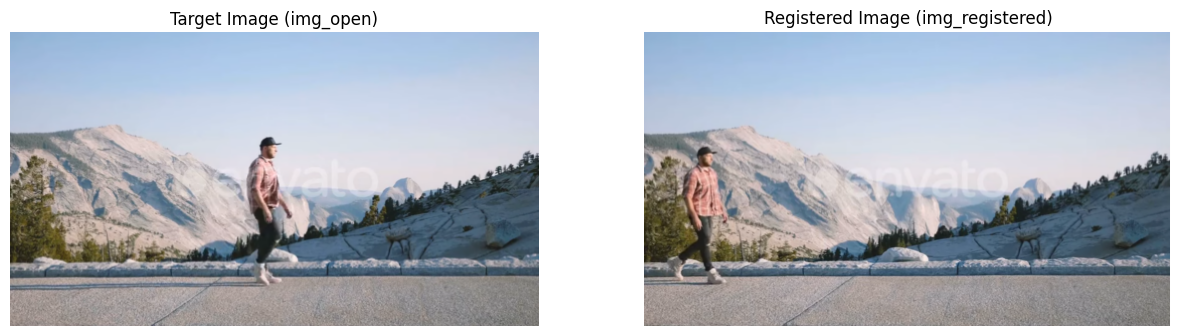

Displayed original target image and the registered source image.


In [10]:
import matplotlib.pyplot as plt

# Display the original img_open and the registered image
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_open, cv2.COLOR_BGR2RGB))
plt.title('Target Image (img_open)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_registered, cv2.COLOR_BGR2RGB))
plt.title('Registered Image (img_registered)')
plt.axis('off')

plt.show()
print("Displayed original target image and the registered source image.")

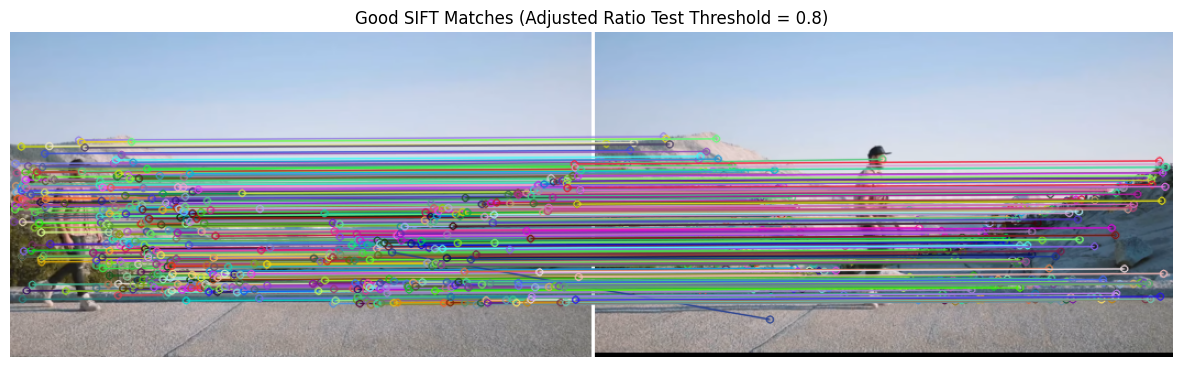

In [11]:
import matplotlib.pyplot as plt

# Draw good matches with the adjusted threshold
img_matches_adjusted = cv2.drawMatches(img_close, kp_close, img_open, kp_open, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img_matches_adjusted, cv2.COLOR_BGR2RGB))
plt.title(f'Good SIFT Matches (Adjusted Ratio Test Threshold = {RATIO_TEST_THRESHOLD})')
plt.axis('off')
plt.show()

In [13]:
import numpy as np

# 1. SIFT

# 2. Detect keypoints and compute descriptors for img_close (object) and img_open (scene)

# 3. Brute-Force Matcher

# 4. Find k-nearest neighbors (k=2) for each descriptor from the object in the scene
matches_obj_scene = bf.knnMatch(des_close, des_open, k=2)
print(f"Found {len(matches_obj_scene)} potential matches between object and scene.")

# 5. Apply ratio test to filter good matches
good_matches_obj_scene = []
RATIO_TEST_THRESHOLD_OBJ = 0.8
for m, n in matches_obj_scene:
    if m.distance < RATIO_TEST_THRESHOLD_OBJ * n.distance:
        good_matches_obj_scene.append(m)
print(f"Filtered down to {len(good_matches_obj_scene)} good matches for object recognition using adjusted ratio test (threshold={RATIO_TEST_THRESHOLD_OBJ}).")

# 6. Extract coordinates of matched keypoints
if len(good_matches_obj_scene):
    src_pts_obj = np.float32([kp_close[m.queryIdx].pt for m in good_matches_obj_scene]).reshape(-1, 1, 2)
    dst_pts_obj = np.float32([kp_open[m.trainIdx].pt for m in good_matches_obj_scene]).reshape(-1, 1, 2)
    print("Extracted matched keypoint coordinates for object recognition.")

    # 7. Estimate homography matrix to find the object in the scene
    M_object, mask_object = cv2.findHomography(src_pts_obj, dst_pts_obj, cv2.RANSAC, 5.0)

    if M_object is not None:

        # 8. Draw a bounding box around the detected object in the scene
        h_obj, w_obj, _ = img_close.shape
        pts_corners = np.float32([[0, 0], [0, h_obj - 1], [w_obj - 1, h_obj - 1], [w_obj - 1, 0]]).reshape(-1, 1, 2)
        dst_corners = cv2.perspectiveTransform(pts_corners, M_object)

        img_object_detected = img_open.copy()
        img_object_detected = cv2.polylines(img_object_detected, [np.int32(dst_corners)], True, (0, 255, 0), 3, cv2.LINE_AA)
        print("Object detected and bounding box drawn in the scene.")



Found 817 potential matches between object and scene.
Filtered down to 475 good matches for object recognition using adjusted ratio test (threshold=0.8).
Extracted matched keypoint coordinates for object recognition.
Object detected and bounding box drawn in the scene.


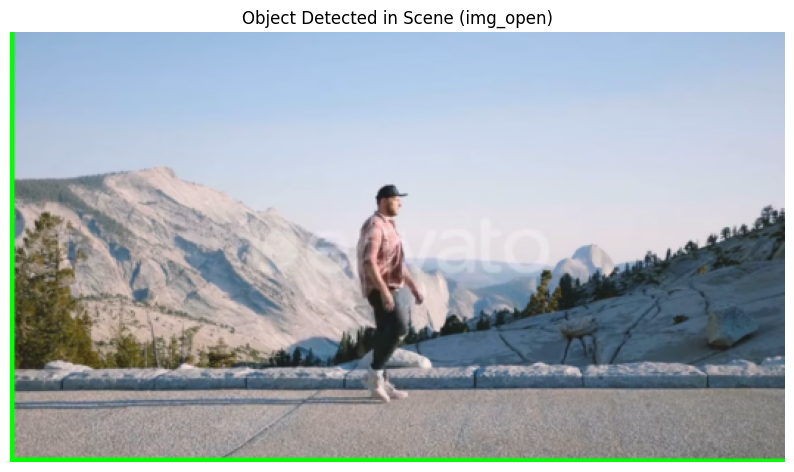

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_object_detected, cv2.COLOR_BGR2RGB))
plt.title('Object Detected in Scene (img_open)')
plt.axis('off')
plt.show()